In [4]:
# File to apply the Maréchal approximation for the different GPAOs modes
#   - NGS_VIS   -> 40x40 SH-WFS
#   - NGS_IR    -> 9x9 SH-WFS
#   - LGS_VIS   -> 30x30 LGS + 4x4 SH-WFS
#   - LGS_IR    -> 30x30 LGS + 9x9 SH-WFS
# 
# Created: 06/09/2023 (mm/dd/yyyy)
# Author: Anthony Berdeu (LIRA - Observatoire de Paris)
########################################################################

#######################
# IMPORTING LIBRARIES #
#######################

# Python
import os
import numpy as np
import importlib

# aspro
import aspro as aspro
importlib.reload(aspro)



<module 'aspro' from '/home/bourgesl/dev/ASPRO_LGS/aspro.py'>

In [21]:
# Example on a single Strehl #
##############################

# Target
flag_mode = 'LGS_IR'
config_target = {}
config_target['wavelength'] = 2.2e-06 # Wavelength of the target (science or fringe tracker) channel (m)
config_target['zenith'] = 15 # Pointing angle to zenith for the airmass (deg)

# Loading TIPTOP fit and configuration
[config_Strehl, config_WFS_NGS, config_WFS_LGS] = aspro.get_mode_config(flag_mode) 

# Turbulence
config_turbulence = {}
config_turbulence['r_0'] = 0.100 # Fried's parameter @500 nm (m)
config_turbulence['v_0'] = [15.0] # Wind speed of the turbulence layers (m.s-1) (could be a list) (for isoplanetism)
config_turbulence['h_0'] = [1500.0] # Altitude of the turbulent layers (m) (could be a list) (for isoplanetism)
config_turbulence['Cn2'] = [1] # Cn2 weight (could be a list) (for collapsing h_0 and v_0 to an equivalent individual layer)
#config_turbulence['v_0'] = [12.3, 8.3, 30.4, 56, 32] # Wind speed of the turbulence layers (m.s-1) (could be a list) (for isoplanetism)
#config_turbulence['h_0'] = [30, 562, 4500, 7750, 14000] # Altitude of the turbulent layers (m) (could be a list) (for isoplanetism)
# config_turbulence['Cn2'] = [12.3, 8.3, 30.4, 56, 32] # Cn2 weight (could be a list) (for collapsing h_0 and v_0 to an equivalent individual layer)


# AO configuration
config_ao = {}
config_ao['magnitude_NGS'] = 8
config_ao['n_mode'] = 500
config_ao['f_loop_NGS'] = 500
config_ao['g_loop_NGS'] = 0.5
config_ao['theta_NGS'] = 0
config_ao['f_loop_LGS'] = 1000
config_ao['g_loop_LGS'] = 0.5
config_ao['theta_LGS'] = 0

# Running Maréchal approximation
SR_Maréchal = aspro.compute_Maréchal(flag_mode, config_target, config_turbulence, config_ao, config_Strehl, config_WFS_NGS, config_WFS_LGS)
print('Strehl ratio: ', SR_Maréchal)

Strehl ratio:  0.6627186993231053


/tmp/ipykernel_32165/2707683940.py:303: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  list_SR_Maréchal[mag,i] = aspro.compute_Maréchal(list_flag_mode[i], list_config_target[i], list_config_turbulence[i], list_config_ao[i], list_config_Strehl[i], list_config_WFS_NGS[i], list_config_WFS_LGS[i])


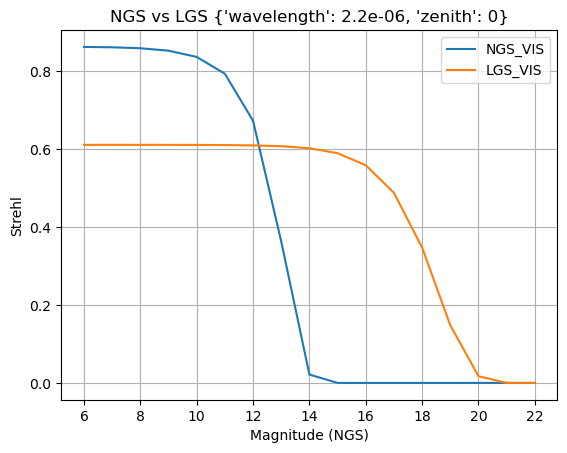

In [14]:
# Comparing modes #
###################

# matplotlib
from astropy.io import fits
import matplotlib.pyplot as plt


# Tiptop
import importlib
import aspro
importlib.reload(aspro)



name_error = 'NGS_vs_LGS'

if name_error == 'NGS_vs_f_loop':
    flag_mode = 'LGS_VIS'
    
    # Loop on magnitude
    mag_min = 6
    mag_max = 22
    mag_delta = 0.1
    mag_nb = round((mag_max-mag_min)/mag_delta+1)
    list_mag = np.zeros([mag_nb, 1])
    list_mag[:,0] = np.linspace(mag_min, mag_max, mag_nb)
    xlabel = 'Magnitude (NGS)'

    # Loop on frequency
    list_freq = np.array([100, 250, 500, 1000])
    nb_test = list_freq.shape[0]

    # Target
    config_target = {}
    config_target['wavelength'] = 2.2e-06 # Wavelength of the target (science or fringe tracker) channel (m)
    config_target['zenith'] = 15 # Pointing angle to zenith for the airmass (deg)

    # Turbulence
    config_turbulence = {}
    config_turbulence['r_0'] = 0.100 # Fried's parameter @500 nm (m)
    config_turbulence['v_0'] = [25.0] # Wind speed of the turbulence layers (m.s-1) (could be a list) (for isoplanetism)
    config_turbulence['h_0'] = [1500.0] # Altitude of the turbulent layers (m) (could be a list) (for isoplanetism)
    config_turbulence['Cn2'] = [1] # Cn2 weight (could be a list) (for collapsing h_0 and v_0 to an equivalent individual layer)

    # Generating cases
    list_label = [None] * nb_test
    list_flag_mode = [None] * nb_test
    list_config_target = [None] * nb_test
    list_config_turbulence = [None] * nb_test
    list_config_ao = [None] * nb_test
    list_config_Strehl = [None] * nb_test
    list_config_WFS_NGS = [None] * nb_test
    list_config_WFS_LGS = [None] * nb_test
    for i in range(nb_test):
        list_label[i] = 'f_loop = ' + np.array2string(list_freq[i], separator=', ') + ' (Hz)'
        list_flag_mode[i] = flag_mode
        list_config_target[i] = config_target
        list_config_turbulence[i] = config_turbulence


        # AO configuration
        if list_flag_mode[i][0:3]=='NGS':
            config_ao = {}
            config_ao['magnitude_NGS'] = 0
            config_ao['n_mode'] = 500
            config_ao['f_loop_NGS'] = list_freq[i]
            config_ao['g_loop_NGS'] = 0.5
            config_ao['theta_NGS'] = 0
        else:
            config_ao = {}
            config_ao['magnitude_NGS'] = 0
            config_ao['n_mode'] = 500
            config_ao['f_loop_NGS'] = list_freq[i]
            config_ao['g_loop_NGS'] = 0.3
            config_ao['theta_NGS'] = 0
            config_ao['f_loop_LGS'] = 1000
            config_ao['g_loop_LGS'] = 0.5
            config_ao['theta_LGS'] = 0
            

        list_config_ao[i] = config_ao
        [list_config_Strehl[i], list_config_WFS_NGS[i], list_config_WFS_LGS[i]] = aspro.get_mode_config(list_flag_mode[i])

elif name_error == 'NGS_vs_g_loop':
    flag_mode = 'LGS_VIS'
    
    # Loop on magnitude
    mag_min = 6
    mag_max = 22
    mag_delta = 0.1
    mag_nb = round((mag_max-mag_min)/mag_delta+1)
    list_mag = np.zeros([mag_nb, 1])
    list_mag[:,0] = np.linspace(mag_min, mag_max, mag_nb)
    xlabel = 'Magnitude (NGS)'

    # Loop on frequency
    list_test = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
    nb_test = list_test.shape[0]

    # Target
    config_target = {}
    config_target['wavelength'] = 2.2e-06 # Wavelength of the target (science or fringe tracker) channel (m)
    config_target['zenith'] = 15 # Pointing angle to zenith for the airmass (deg)

    # Turbulence
    config_turbulence = {}
    config_turbulence['r_0'] = 0.100 # Fried's parameter @500 nm (m)
    config_turbulence['v_0'] = [25.0] # Wind speed of the turbulence layers (m.s-1) (could be a list) (for isoplanetism)
    config_turbulence['h_0'] = [1500.0] # Altitude of the turbulent layers (m) (could be a list) (for isoplanetism)
    config_turbulence['Cn2'] = [1] # Cn2 weight (could be a list) (for collapsing h_0 and v_0 to an equivalent individual layer)

    # Generating cases
    list_label = [None] * nb_test
    list_flag_mode = [None] * nb_test
    list_config_target = [None] * nb_test
    list_config_turbulence = [None] * nb_test
    list_config_ao = [None] * nb_test
    list_config_Strehl = [None] * nb_test
    list_config_WFS_NGS = [None] * nb_test
    list_config_WFS_LGS = [None] * nb_test
    for i in range(nb_test):
        list_label[i] = 'g_loop = ' + np.array2string(list_test[i], separator=', ')
        list_flag_mode[i] = flag_mode
        list_config_target[i] = config_target
        list_config_turbulence[i] = config_turbulence


        # AO configuration
        if list_flag_mode[i][0:3]=='NGS':
            config_ao = {}
            config_ao['magnitude_NGS'] = 0
            config_ao['n_mode'] = 500
            config_ao['f_loop_NGS'] = 1000
            config_ao['g_loop_NGS'] = list_test[i]
            config_ao['theta_NGS'] = 0
        else:
            config_ao = {}
            config_ao['magnitude_NGS'] = 0
            config_ao['n_mode'] = 500
            config_ao['f_loop_NGS'] = 1000
            config_ao['g_loop_NGS'] = list_test[i]
            config_ao['theta_NGS'] = 0
            config_ao['f_loop_LGS'] = 1000
            config_ao['g_loop_LGS'] = 0.5
            config_ao['theta_LGS'] = 0
            

        list_config_ao[i] = config_ao
        [list_config_Strehl[i], list_config_WFS_NGS[i], list_config_WFS_LGS[i]] = aspro.get_mode_config(list_flag_mode[i])


elif name_error == 'theta_NGS':
    flag_mode = 'LGS_VIS'
    
    # Loop on magnitude
    mag_min = 6
    mag_max = 22
    mag_delta = 0.1
    mag_nb = round((mag_max-mag_min)/mag_delta+1)
    list_mag = np.zeros([mag_nb, 1])
    list_mag[:,0] = np.linspace(mag_min, mag_max, mag_nb)
    xlabel = 'Magnitude (NGS)'

    # Loop on frequency
    theta_min = 0
    theta_max = 50
    theta_delta = 5
    nb_test = round((theta_max-theta_min)/theta_delta+1)
    list_test = np.zeros([nb_test, 1])
    list_test[:,0] = np.linspace(theta_min, theta_max, nb_test)

    # Target
    config_target = {}
    config_target['wavelength'] = 2.2e-06 # Wavelength of the target (science or fringe tracker) channel (m)
    config_target['zenith'] = 15 # Pointing angle to zenith for the airmass (deg)

    # Turbulence
    config_turbulence = {}
    config_turbulence['r_0'] = 0.100 # Fried's parameter @500 nm (m)
    config_turbulence['v_0'] = [25.0] # Wind speed of the turbulence layers (m.s-1) (could be a list) (for isoplanetism)
    config_turbulence['h_0'] = [1500.0] # Altitude of the turbulent layers (m) (could be a list) (for isoplanetism)
    config_turbulence['Cn2'] = [1] # Cn2 weight (could be a list) (for collapsing h_0 and v_0 to an equivalent individual layer)

    # Generating cases
    list_label = [None] * nb_test
    list_flag_mode = [None] * nb_test
    list_config_target = [None] * nb_test
    list_config_turbulence = [None] * nb_test
    list_config_ao = [None] * nb_test
    list_config_Strehl = [None] * nb_test
    list_config_WFS_NGS = [None] * nb_test
    list_config_WFS_LGS = [None] * nb_test
    for i in range(nb_test):
        list_label[i] = 'theta_NGS = ' + np.array2string(list_test[i], separator=', ') + ' (deg)'
        list_flag_mode[i] = flag_mode
        list_config_target[i] = config_target
        list_config_turbulence[i] = config_turbulence


        # AO configuration
        if list_flag_mode[i][0:3] == 'NGS':
            config_ao = {}
            config_ao['magnitude_NGS'] = 0
            config_ao['n_mode'] = 500
            config_ao['f_loop_NGS'] = 1000
            config_ao['g_loop_NGS'] = 0.5
            config_ao['theta_NGS'] = list_test[i]
        else:
            config_ao = {}
            config_ao['magnitude_NGS'] = 0
            config_ao['n_mode'] = 500
            config_ao['f_loop_NGS'] = 500
            config_ao['g_loop_NGS'] = 0.3
            config_ao['theta_NGS'] = list_test[i]
            config_ao['f_loop_LGS'] = 1000
            config_ao['g_loop_LGS'] = 0.5
            config_ao['theta_LGS'] = 0
            

        list_config_ao[i] = config_ao
        [list_config_Strehl[i], list_config_WFS_NGS[i], list_config_WFS_LGS[i]] = aspro.get_mode_config(list_flag_mode[i])

elif name_error == 'NGS_vs_LGS':
    
    # Loop on magnitude
    mag_min = 6
    mag_max = 22
    mag_delta = 0.5
    mag_nb = round((mag_max-mag_min)/mag_delta+1)
    list_mag = np.zeros([mag_nb, 1])
    list_mag[:,0] = np.linspace(mag_min, mag_max, mag_nb)
    xlabel = 'Magnitude (NGS)'

    # Defining cases
    nb_test = 2
    list_flag_mode = ['NGS_VIS', 'LGS_VIS']

    # Target
    config_target = {}
    config_target['wavelength'] = 2.2e-06 # Wavelength of the target (science or fringe tracker) channel (m)
    config_target['zenith'] = 0 # Pointing angle to zenith for the airmass (deg)

    # Turbulence
    config_turbulence = {}
    config_turbulence['r_0'] = 0.100 # Fried's parameter @500 nm (m)
    config_turbulence['v_0'] = [25.0] # Wind speed of the turbulence layers (m.s-1) (could be a list) (for isoplanetism)
    config_turbulence['h_0'] = [1500.0] # Altitude of the turbulent layers (m) (could be a list) (for isoplanetism)
    config_turbulence['Cn2'] = [1] # Cn2 weight (could be a list) (for collapsing h_0 and v_0 to an equivalent individual layer)

    # Generating cases
    list_label = [None] * nb_test
    list_config_target = [None] * nb_test
    list_config_turbulence = [None] * nb_test
    list_config_ao = [None] * nb_test
    list_config_Strehl = [None] * nb_test
    list_config_WFS_NGS = [None] * nb_test
    list_config_WFS_LGS = [None] * nb_test
    for i in range(nb_test):
        list_label[i] = list_flag_mode[i]
        
        list_config_target[i] = config_target
        list_config_turbulence[i] = config_turbulence


        # AO configuration
        if list_flag_mode[i][0:3] == 'NGS':
            config_ao = {}
            config_ao['magnitude_NGS'] = 0
            config_ao['n_mode'] = 500
            config_ao['f_loop_NGS'] = 1000
            config_ao['g_loop_NGS'] = 0.5
            config_ao['theta_NGS'] = 0
            config_ao['f_loop_LGS'] = 1000
            config_ao['g_loop_LGS'] = 0.5
            config_ao['theta_LGS'] = 0
        else:
            config_ao = {}
            config_ao['magnitude_NGS'] = 0
            config_ao['n_mode'] = 500
            config_ao['f_loop_NGS'] = 500
            config_ao['g_loop_NGS'] = 0.3
            config_ao['theta_NGS'] = 0
            config_ao['f_loop_LGS'] = 1000
            config_ao['g_loop_LGS'] = 0.5
            config_ao['theta_LGS'] = 0
            

        list_config_ao[i] = config_ao
        [list_config_Strehl[i], list_config_WFS_NGS[i], list_config_WFS_LGS[i]] = aspro.get_mode_config(list_flag_mode[i])

else:
    raise ValueError('Unknown test')
##### Parameters #####


##### Maréchal #####
list_SR_Maréchal = np.zeros([mag_nb, nb_test])
for i in range(nb_test):
    for mag in range(mag_nb):
        # Running Maréchal approximation
        list_config_ao[i]['magnitude_NGS'] = list_mag[mag]
        list_SR_Maréchal[mag,i] = aspro.compute_Maréchal(list_flag_mode[i], list_config_target[i], list_config_turbulence[i], list_config_ao[i], list_config_Strehl[i], list_config_WFS_NGS[i], list_config_WFS_LGS[i])
##### Maréchal #####


##### Display results #####
plt.figure(0)
plt.clf()
for i in range(nb_test):
    plt.plot(list_mag, list_SR_Maréchal[:,i], label = list_label[i])
plt.xlabel(xlabel)
plt.ylabel('Strehl')
plt.title('NGS vs LGS ' + str(config_target))
plt.grid()
plt.legend()
##### Display results #####


In [17]:
list_mag

array([[ 6.],
       [ 7.],
       [ 8.],
       [ 9.],
       [10.],
       [11.],
       [12.],
       [13.],
       [14.],
       [15.],
       [16.],
       [17.],
       [18.],
       [19.],
       [20.],
       [21.],
       [22.]])

In [18]:
list_SR_Maréchal

array([[8.62578914e-001, 6.11159295e-001],
       [8.61611982e-001, 6.11151019e-001],
       [8.59170544e-001, 6.11130231e-001],
       [8.52959427e-001, 6.11078018e-001],
       [8.36880312e-001, 6.10946883e-001],
       [7.93768505e-001, 6.10617613e-001],
       [6.73071538e-001, 6.09791305e-001],
       [3.63244159e-001, 6.07720644e-001],
       [2.15060361e-002, 6.02550348e-001],
       [5.60188952e-009, 5.89756387e-001],
       [1.32619045e-047, 5.58805129e-001],
       [5.49841413e-284, 4.88037217e-001],
       [0.00000000e+000, 3.47332102e-001],
       [0.00000000e+000, 1.47835833e-001],
       [0.00000000e+000, 1.73116824e-002],
       [0.00000000e+000, 7.96300984e-005],
       [0.00000000e+000, 1.11006948e-010]])